<a href="https://colab.research.google.com/github/awalinrizky/praktikum1_IR/blob/main/IR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
df = pd.read_xml('/content/drive/MyDrive/IR/praktikum1/data/kompas-beritaPart1.xml')
df.head()

,sumber,tanggal,kategori,judul,isi,link,jumlahkata
0,kompas.com,2015/07/01,Teknologi,"Ponsel Huawei Honor 4C Dibanderol Rp 2,2 Juta","JAKARTA, KOMPAS.com Ponsel Android Huawei Hon...",http://tekno.kompas.com/read/xml/2015/07/01/18...,315
1,kompas.com,2015/07/01,Teknologi,Asosiasi: RPP E-commerce Tidak Sesuai Hasil Di...,"JAKARTA, KOMPAS.com - Sejak 2013, wacana tenta...",http://tekno.kompas.com/read/xml/2015/07/01/16...,419
2,kompas.com,2015/07/01,Teknologi,"Pemesan ""iPhone Jadi Sabun"" Karyawan Pesaing L...","JAKARTA, KOMPAS.com Danis Darusman, pelanggan ...",http://tekno.kompas.com/read/xml/2015/07/01/15...,265
3,kompas.com,2015/07/01,Teknologi,"""Autofeather Failure"", Momok bagi Pesawat Bali...",KOMPAS.com Salah satu momok yang dihadapi dala...,http://tekno.kompas.com/read/xml/2015/07/01/14...,481
4,kompas.com,2015/07/01,Teknologi,Laptop Bezel Tertipis di Dunia Masuk Indonesia,"JAKARTA, KOMPAS.com - Resmi diperkenalkan pada...",http://tekno.kompas.com/read/xml/2015/07/01/14...,227


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sumber      1502 non-null   object
 1   tanggal     1502 non-null   object
 2   kategori    1502 non-null   object
 3   judul       1502 non-null   object
 4   isi         1502 non-null   object
 5   link        1502 non-null   object
 6   jumlahkata  1502 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 82.3+ KB


In [13]:
df.isnull().sum()

,0
sumber,0
tanggal,0
kategori,0
judul,0
isi,0
link,0
jumlahkata,0


In [14]:
def casefolding(text):
  text = text.lower()
  return text

contoh = "Terima Kasih, Kak! Kamu sangat baik sekali hari ini."
print(f'original: {contoh}')
print(f'case folded: {casefolding(contoh)}')

original: Terima Kasih, Kak! Kamu sangat baik sekali hari ini.
case folded: terima kasih, kak! kamu sangat baik sekali hari ini.


In [15]:
import re

def puntuactionRemoval(text):
  text = re.sub(r'[^\w\s]', '', text)
  return text

contoh = "Terima Kasih, Kak! Kamu sangat baik sekali hari ini."
print(f'original: {contoh}')
print(f'puntuaction removed: {puntuactionRemoval(contoh)}')

original: Terima Kasih, Kak! Kamu sangat baik sekali hari ini.
puntuaction removed: Terima Kasih Kak Kamu sangat baik sekali hari ini


In [16]:
df['clean'] = df['isi'].apply(casefolding)
df['clean'] = df['clean'].apply(puntuactionRemoval)
df.head()

,sumber,tanggal,kategori,judul,isi,link,jumlahkata,clean
0,kompas.com,2015/07/01,Teknologi,"Ponsel Huawei Honor 4C Dibanderol Rp 2,2 Juta","JAKARTA, KOMPAS.com Ponsel Android Huawei Hon...",http://tekno.kompas.com/read/xml/2015/07/01/18...,315,jakarta kompascom ponsel android huawei honor...
1,kompas.com,2015/07/01,Teknologi,Asosiasi: RPP E-commerce Tidak Sesuai Hasil Di...,"JAKARTA, KOMPAS.com - Sejak 2013, wacana tenta...",http://tekno.kompas.com/read/xml/2015/07/01/16...,419,jakarta kompascom sejak 2013 wacana tentang r...
2,kompas.com,2015/07/01,Teknologi,"Pemesan ""iPhone Jadi Sabun"" Karyawan Pesaing L...","JAKARTA, KOMPAS.com Danis Darusman, pelanggan ...",http://tekno.kompas.com/read/xml/2015/07/01/15...,265,jakarta kompascom danis darusman pelanggan laz...
3,kompas.com,2015/07/01,Teknologi,"""Autofeather Failure"", Momok bagi Pesawat Bali...",KOMPAS.com Salah satu momok yang dihadapi dala...,http://tekno.kompas.com/read/xml/2015/07/01/14...,481,kompascom salah satu momok yang dihadapi dalam...
4,kompas.com,2015/07/01,Teknologi,Laptop Bezel Tertipis di Dunia Masuk Indonesia,"JAKARTA, KOMPAS.com - Resmi diperkenalkan pada...",http://tekno.kompas.com/read/xml/2015/07/01/14...,227,jakarta kompascom resmi diperkenalkan pada aj...


In [17]:
def tokenize(text):
  return text.split()

contoh = "Terima Kasih, Kak! Kamu sangat baik sekali hari ini."
print(f'original: {contoh}')

clean = casefolding(contoh)
clean = puntuactionRemoval(clean)
print(f'tokenized: {tokenize(clean)}')

original: Terima Kasih, Kak! Kamu sangat baik sekali hari ini.
tokenized: ['terima', 'kasih', 'kak', 'kamu', 'sangat', 'baik', 'sekali', 'hari', 'ini']


In [18]:
df['tokens'] = df['clean'].apply(tokenize)
df.head()

,sumber,tanggal,kategori,judul,isi,link,jumlahkata,clean,tokens
0,kompas.com,2015/07/01,Teknologi,"Ponsel Huawei Honor 4C Dibanderol Rp 2,2 Juta","JAKARTA, KOMPAS.com Ponsel Android Huawei Hon...",http://tekno.kompas.com/read/xml/2015/07/01/18...,315,jakarta kompascom ponsel android huawei honor...,"[jakarta, kompascom, ponsel, android, huawei, ..."
1,kompas.com,2015/07/01,Teknologi,Asosiasi: RPP E-commerce Tidak Sesuai Hasil Di...,"JAKARTA, KOMPAS.com - Sejak 2013, wacana tenta...",http://tekno.kompas.com/read/xml/2015/07/01/16...,419,jakarta kompascom sejak 2013 wacana tentang r...,"[jakarta, kompascom, sejak, 2013, wacana, tent..."
2,kompas.com,2015/07/01,Teknologi,"Pemesan ""iPhone Jadi Sabun"" Karyawan Pesaing L...","JAKARTA, KOMPAS.com Danis Darusman, pelanggan ...",http://tekno.kompas.com/read/xml/2015/07/01/15...,265,jakarta kompascom danis darusman pelanggan laz...,"[jakarta, kompascom, danis, darusman, pelangga..."
3,kompas.com,2015/07/01,Teknologi,"""Autofeather Failure"", Momok bagi Pesawat Bali...",KOMPAS.com Salah satu momok yang dihadapi dala...,http://tekno.kompas.com/read/xml/2015/07/01/14...,481,kompascom salah satu momok yang dihadapi dalam...,"[kompascom, salah, satu, momok, yang, dihadapi..."
4,kompas.com,2015/07/01,Teknologi,Laptop Bezel Tertipis di Dunia Masuk Indonesia,"JAKARTA, KOMPAS.com - Resmi diperkenalkan pada...",http://tekno.kompas.com/read/xml/2015/07/01/14...,227,jakarta kompascom resmi diperkenalkan pada aj...,"[jakarta, kompascom, resmi, diperkenalkan, pad..."


In [20]:
from collections import Counter

all_token = []
for tokens in df['tokens']:
    for token in tokens:
        all_token.append(token)

term_freq = Counter(all_token)

# Buat DataFrame dari pasangan (term, freq)
term_freq_df = pd.DataFrame(list(term_freq.items()), columns=['term','freq'])

# Jika perlu sort
term_freq_df_sorted = term_freq_df.sort_values(by='freq', ascending=False).reset_index(drop=True)

term_freq_df_sorted.head()

,term,freq
0,yang,6450
1,di,5824
2,dan,4915
3,ini,2744
4,dengan,2625


In [21]:
term_freq_df_sorted['rank'] = term_freq_df_sorted['freq'].rank(ascending=False, method='min')
term_freq_df_sorted.head()

,term,freq,rank
0,yang,6450,1.0
1,di,5824,2.0
2,dan,4915,3.0
3,ini,2744,4.0
4,dengan,2625,5.0


In [23]:
term_freq_df_sorted['Rank'] = term_freq_df_sorted['freq'].rank(method='first', ascending=False).astype(int)

tf_sorted_ran = term_freq_df_sorted.sort_values(by='Rank', ascending=True)
tf_sorted_ran.head(20)

,term,freq,rank,Rank
0,yang,6450,1.0,1
1,di,5824,2.0,2
2,dan,4915,3.0,3
3,ini,2744,4.0,4
4,dengan,2625,5.0,5
5,untuk,2583,6.0,6
6,dari,2460,7.0,7
7,itu,2437,8.0,8
8,akan,2055,9.0,9
9,dalam,1743,10.0,10


In [24]:
term_freq_df_sorted['k = f * r'] = term_freq_df_sorted['freq'] * term_freq_df_sorted['rank']
term_freq_df_sorted.head(n=100)

,term,freq,rank,Rank,k = f * r
0,yang,6450,1.0,1,6450.0
1,di,5824,2.0,2,11648.0
2,dan,4915,3.0,3,14745.0
3,ini,2744,4.0,4,10976.0
4,dengan,2625,5.0,5,13125.0
...,...,...,...,...,...
95,dapat,360,95.0,96,34200.0
96,republikacoid,352,97.0,97,34144.0
97,lain,350,98.0,98,34300.0
98,negara,345,99.0,99,34155.0


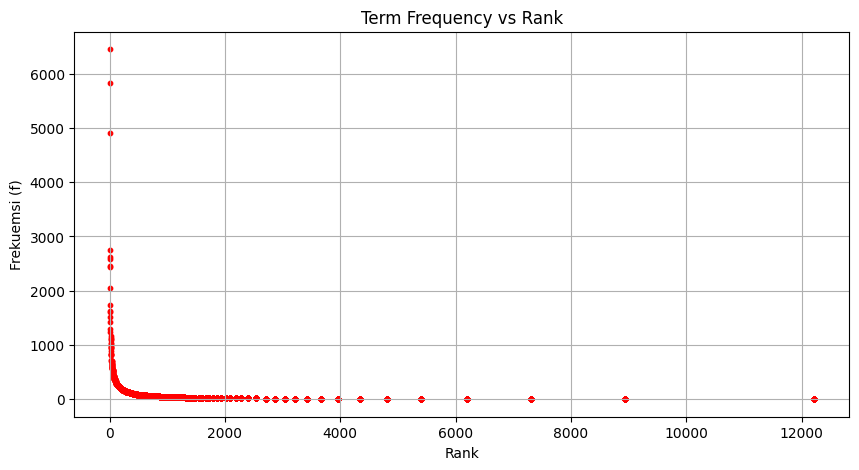

In [26]:
import matplotlib.pyplot as plt

rank = term_freq_df_sorted['rank']
freq = term_freq_df_sorted['freq']

plt.figure(figsize=(10, 5))
plt.scatter(rank, freq, color='red', s=10)
plt.title("Term Frequency vs Rank")
plt.xlabel("Rank")
plt.ylabel("Frekuemsi (f)")

plt.grid(True)
plt.show()